# Shallow Water Tutorial 1D with Numpy (Simple)


::: {.callout-note title="Reference"}
The following the model is described in the paper: 

```
 @article{Delestre_2013, 
 title={SWASHES: a compilation of Shallow Water Analytic Solutions for Hydraulic and Environmental Studies}, 
 volume={72}, 
 ISSN={0271-2091, 1097-0363}, DOI={10.1002/fld.3741}, 
 note={arXiv:1110.0288 [physics]}, 
 number={3}, 
 journal={International Journal for Numerical Methods in Fluids}, 
 author={Delestre, Olivier and Lucas, Carine and Ksinant, Pierre-Antoine and Darboux, Frédéric and Laguerre, Christian and Vo, Thi Ngoc Tuoi and James, Francois and Cordier, Stephane}, 
 year={2013}, 
 month=may, 
 pages={269–300} 
}
```

:::

## Imports

In [1]:
# | code-fold: true
# | code-summary: "Load packages"
# | output: false

import os
import numpy as np
import pytest
from sympy import Matrix
import pytest
import param

from zoomy_core.fvm.solver_numpy import HyperbolicSolver, Settings
import zoomy_core.fvm.timestepping as timestepping
import zoomy_core.fvm.nonconservative_flux as nc_flux
from zoomy_core.model.basemodel import Model
from attr import field, define
import zoomy_core.model.initial_conditions as IC
import zoomy_core.model.boundary_conditions as BC
import zoomy_core.misc.io as io
from zoomy_core.mesh.mesh import compute_derivatives
from zoomy_core.misc.misc import Zstruct, ZArray
import zoomy_core.misc.misc as misc
from zoomy_tests.swashes import plots_paper


import zoomy_core.mesh.mesh as petscMesh
import zoomy_core.postprocessing.postprocessing as postprocessing


In [2]:
class SWE(Model):
    """
    Shallow Water Equations (SWE) Model.
    Supports 1D and 2D configurations automatically based on 'dimension'.
    """

    # --- 1. Configuration & Physics Constants ---
    dimension = param.Integer(default=1)
    
    # Define variables dynamically based on dimension (h, hu, [hv])
    variables = lambda self: self.dimension + 1

    # Aux variables for topography (dh/dx)
    aux_variables = 1

    # These parameters are automatically detected by the base Model
    # and made available as symbols in self.parameters (e.g., self.parameters.g)
    g = param.Number(default=9.81, doc="Gravitational acceleration")
    ex = param.Number(default=0.0, doc="Gravity vector x-component")
    ey = param.Number(default=0.0, doc="Gravity vector y-component")
    ez = param.Number(default=1.0, doc="Gravity vector z-component")

    # --- 2. Physics (Conservation Laws) ---

    def flux(self):
        # 1. Setup
        dim = self.dimension
        h = self.variables[0]
        hu_vec = self.variables[1 : 1 + dim]

        # 2. Helper Variables
        # Use self.parameters.name for physics constants
        g = self.parameters.g
        U = Matrix([hu / h for hu in hu_vec])  # Velocity vector
        I = Matrix.eye(dim)

        # 3. Flux Tensor Construction
        # Rows = Equations (Mass, Momentum X, Momentum Y)
        # Cols = Spatial Dimensions (Flux in X, Flux in Y)
        F = Matrix.zeros(self.n_variables, dim)

        # Mass Flux: h * U
        F[0, :] = (h * U).T

        # Momentum Flux: hUU^T + 0.5gh^2I
        F[1:, :] = h * U * U.T + (g / 2) * h**2 * I

        # Return list of columns [Flux_X, Flux_Y]
        return ZArray(F)

    # --- 3. Visualization Logic ---

    def project_2d_to_3d(self):
        out = ZArray.zeros(6)
        dim = self.dimension
        z = self.position[2]

        # Unpack state
        h = self.variables[0]
        hu_vec = self.variables[1 : 1 + dim]
        U = [hu / h for hu in hu_vec]

        # Visualization Constants
        rho_w = 1000.0
        g = 9.81
        b = 0  # Bathymetry placeholder

        # Map to 3D visualization vector
        out[0] = b
        out[1] = h
        out[2] = U[0]
        out[3] = 0 if dim == 1 else U[1]  # v-velocity
        out[4] = 0  # w-velocity
        out[5] = rho_w * g * h * (1 - z)  # Hydrostatic pressure
        return out


In [11]:

bcs = BC.BoundaryConditions(
    [
        BC.Extrapolation(tag="left"),
        BC.Extrapolation(tag="right"),
    ]
)

def custom_ic(x):
    Q = np.zeros(2, dtype=float)
    Q[0] = np.where(x[0] < 5., 0.005, 0.001)
    return Q

ic = IC.UserFunction(custom_ic)

model = SWE(
    boundary_conditions=bcs,
    initial_conditions=ic,
)

main_dir = os.getenv("ZOOMY_DIR")
# mesh = petscMesh.Mesh.from_gmsh(
#     os.path.join(main_dir, "meshes/channel_quad_2d/mesh.msh")
# )

mesh = petscMesh.Mesh.create_1d(domain=(0.0, 10.0), n_inner_cells=500)

class SWESolver(HyperbolicSolver):
    def update_qaux(self, Q, Qaux, Qold, Qauxold, mesh, model, parameters, time, dt):
        dudx = compute_derivatives(Q[1]/Q[0], mesh, derivatives_multi_index=[[0, 0]])[:,0]
        Qaux[0]=dudx
        return Qaux
    
settings = Settings(name="ShallowWater", output=Zstruct(directory="outputs/shallow_water_1d", filename="swe", clean_directory=True, snapshots=2))


In [12]:
solver = SWESolver(time_end=6.0, settings=settings, compute_dt=timestepping.adaptive(CFL=0.95))
Qnew, Qaux = solver.solve(mesh, model)

2026-01-09 15:25:14.782 | INFO     | zoomy_core.fvm.solver_numpy:run:285 - iteration: 10, time: 0.718260, dt: 0.067958, next write at time: 6.000000
2026-01-09 15:25:14.806 | INFO     | zoomy_core.fvm.solver_numpy:run:285 - iteration: 20, time: 1.392979, dt: 0.067263, next write at time: 6.000000
2026-01-09 15:25:14.829 | INFO     | zoomy_core.fvm.solver_numpy:run:285 - iteration: 30, time: 2.064282, dt: 0.067054, next write at time: 6.000000
2026-01-09 15:25:14.864 | INFO     | zoomy_core.fvm.solver_numpy:run:285 - iteration: 40, time: 2.734237, dt: 0.066956, next write at time: 6.000000
2026-01-09 15:25:14.891 | INFO     | zoomy_core.fvm.solver_numpy:run:285 - iteration: 50, time: 3.403455, dt: 0.066898, next write at time: 6.000000
2026-01-09 15:25:14.915 | INFO     | zoomy_core.fvm.solver_numpy:run:285 - iteration: 60, time: 4.072203, dt: 0.066858, next write at time: 6.000000
2026-01-09 15:25:14.938 | INFO     | zoomy_core.fvm.solver_numpy:run:285 - iteration: 70, time: 4.740621, 

In [13]:
io.generate_vtk(os.path.join(settings.output.directory, f"{settings.output.filename}.h5"))
postprocessing.vtk_project_2d_to_3d(model, settings, filename='out_3d')

2026-01-09 15:25:15.093 | INFO     | zoomy_core.postprocessing.postprocessing:vtk_project_2d_to_3d:76 - Converted snapshot 0/2
2026-01-09 15:25:15.096 | INFO     | zoomy_core.postprocessing.postprocessing:vtk_project_2d_to_3d:76 - Converted snapshot 1/2
2026-01-09 15:25:15.106 | INFO     | zoomy_core.postprocessing.postprocessing:vtk_project_2d_to_3d:79 - Output is written to: /home/ingo/Git/Zoomy/outputs/shallow_water_1d/out_3d.h5/out_3d.*.vtk


{'length': 10.0, 'width': None, 'dx': 0.2, 'dy': None, 'ncellx': 50.0, 'ncelly': None}


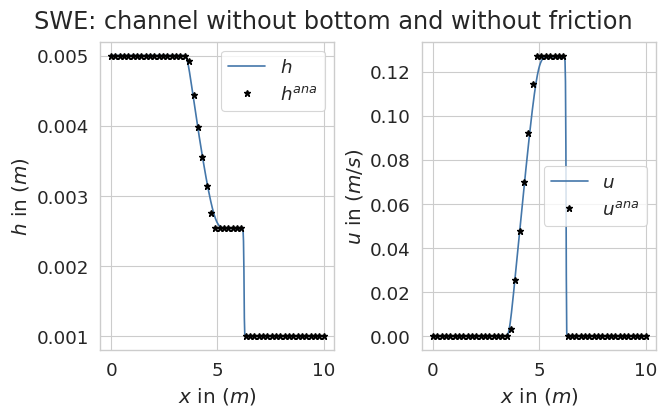

In [6]:
fig = plots_paper.plot_swe(os.path.join(settings.output.directory, settings.output.filename + ".h5"))

# 2D Case

In [14]:
bcs = BC.BoundaryConditions(
    [
        BC.Extrapolation(tag="left"),
        BC.Extrapolation(tag="right"),
        BC.Extrapolation(tag="top"),
        BC.Extrapolation(tag="bottom"),
    ]
)


def custom_ic(x):
    Q = np.zeros(3, dtype=float)
    Q[0] = np.where(x[0] < 5.0, 0.005, 0.001)
    return Q


ic = IC.UserFunction(custom_ic)

model = SWE(
    dimension=2,
    boundary_conditions=bcs,
    initial_conditions=ic,
)

main_dir = misc.get_main_directory()
mesh = petscMesh.Mesh.from_gmsh(
    os.path.join(main_dir, "meshes/channel_quad_2d/mesh.msh")
)

# mesh = petscMesh.Mesh.create_1d(domain=(0.0, 10.0), n_inner_cells=500)


class SWESolver(HyperbolicSolver):
    def update_qaux(self, Q, Qaux, Qold, Qauxold, mesh, model, parameters, time, dt):
        dudx = compute_derivatives(Q[1] / Q[0], mesh, derivatives_multi_index=[[0, 0]])[
            :, 0
        ]
        Qaux[0] = dudx
        return Qaux


settings = Settings(
    name="ShallowWater",
    output=Zstruct(
        directory="outputs/shallow_water_2d", filename="swe", clean_directory=True, snapshots=2
    ),
)


In [8]:
solver = SWESolver(
    time_end=6.0, settings=settings, compute_dt=timestepping.adaptive(CFL=0.95)
)
Qnew, Qaux = solver.solve(mesh, model)


2026-01-09 15:24:46.007 | INFO     | zoomy_core.fvm.solver_numpy:run:285 - iteration: 10, time: 2.244563, dt: 0.212367, next write at time: 6.000000
2026-01-09 15:24:46.275 | INFO     | zoomy_core.fvm.solver_numpy:run:285 - iteration: 20, time: 4.353059, dt: 0.210197, next write at time: 6.000000
2026-01-09 15:24:46.499 | INFO     | zoomy_core.fvm.solver_numpy:solve:295 - Finished simulation with in 0.788 seconds


In [9]:
io.generate_vtk(
    os.path.join(settings.output.directory, f"{settings.output.filename}.h5")
)
postprocessing.vtk_project_2d_to_3d(model, settings, filename="out_3d")


2026-01-09 15:24:46.877 | INFO     | zoomy_core.postprocessing.postprocessing:vtk_project_2d_to_3d:76 - Converted snapshot 0/2
2026-01-09 15:24:46.884 | INFO     | zoomy_core.postprocessing.postprocessing:vtk_project_2d_to_3d:76 - Converted snapshot 1/2
2026-01-09 15:24:46.916 | INFO     | zoomy_core.postprocessing.postprocessing:vtk_project_2d_to_3d:79 - Output is written to: /home/ingo/Git/Zoomy/outputs/shallow_water_2d/out_3d.h5/out_3d.*.vtk


In [10]:
@pytest.mark.nbworking
def test_working():
    assert True